# Output integrity and physical consistency: `tas`, `tasmax`, `tasmin`, `dtr`, `pr`, `rsds`, `hurs`

Quality-control checks on the downscaled outputs the BCSD pipeline publishes, run against the
production stores on Source Cooperative. Three parts:

| Part | Question | Issue |
| --- | --- | --- |
| 1 | Is each output array internally well formed? | [#450](https://github.com/carbonplan/srm-downscaling/issues/450) |
| 2 | How often is `tasmin ≤ tas ≤ tasmax` violated? | [#448](https://github.com/carbonplan/srm-downscaling/issues/448) |
| 3 | Does precipitation stay physically valid? | [#459](https://github.com/carbonplan/srm-downscaling/issues/459) |

They belong together because they follow from one property of the method: BCSD bias-corrects and
disaggregates each variable separately, with no later step re-imposing a joint constraint. That is
why integrity must be checked per array, why the temperature ordering can be distorted, and why
precipitation needs its own physical check.

Both output families named in #450 are covered: the bias-corrected coarse outputs under
`debiased_coarse/…` on the GCM grid, and the downscaled outputs in the top-level scenario groups on
the fine ERA5 grid.

The check machinery lives in `srm.qaqc` and is shared with
[`output-integrity-checks-regional.ipynb`](output-integrity-checks-regional.ipynb), which runs the
same checks against a spatial subset carrying every GCM.

In [1]:
import os

import coiled
import pandas as pd
import zarr
from dask_array.xarray import register
from IPython.display import display

from srm.config import ClusterConfig
from srm.qaqc import (
    check_grids,
    check_groups,
    check_inventory,
    check_no_all_zero,
    check_no_duplicates,
    check_no_nans,
    check_reasonable_ranges,
    check_time_axis,
    check_time_bounds,
    compute_with_retry,
    consistency_summary,
    discover_leaves,
    duplicate_leaves,
    highlight,
    leaf_stats,
    ordering_violations,
    output_group_labels,
    plot_negativity_maps,
    plot_violation_maps,
    pr_high_days,
    pr_physical,
    pr_physical_summary,
    regional_consistency_summary,
    temperature_triplets,
)
from srm.validation import _open_output_datatree

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters: one published store per GCM, same branch --------------------------------
BASE = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production"
BRANCH = "v0.13.0"
# UKESM has production configs but no published global store yet; adding it here is the only
# change needed once it lands, since every leaf is discovered from the tree.
GCMS = ["CESM2-WACCM", "MIROC-ES2H"]
STORE_URI = {gcm: f"{BASE}/{gcm}-ERA5-global.icechunk" for gcm in GCMS}
GROUPS = output_group_labels()

## Compute

The stores are in `us-west-2` and the checks read every cell of several dozen multi-gigabyte
arrays, so this runs on a [Coiled](https://coiled.io) cluster in the same region. Settings mirror
`srm.config.ClusterConfig`, the pipeline's own cluster configuration, and `frisky` keeps progress
visible while the reductions run.

In [2]:
cfg = ClusterConfig(n_workers=[50, 50])
cluster = coiled.Cluster(
    name="srm-qaqc-output-checks",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
    worker_disk_size=200,
)
client = hijack(cluster.get_client())
client

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_src │ Source wheel built from /scratch/synced/src             │
│   coiled_local_src │ Wheel built from                                        │
│                    │ /scratch/coiled-senv-spec/wheels/coiled_local_src/coi   │
│                    │ led_local_src-0.0.0-py3-none-any.whl                    │
│   srm              │ Wheel built from /scratch/synced                        │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

2026-08-07 23:38:24,886 - distributed.deploy.adaptive - INFO - Adaptive scaling started: minimum=50 maximum=50


<frisky.Client: scheduler="wss://cluster-jetij.dask.host/A-wmHN-z-g_zd2VI/frisky-comm?__frisky_dial_host=54.212.127.160" id="client-0">

## The output store layout

One icechunk store per GCM, versioned by branch rather than by path. Within a branch the data sits
in two families sharing a `scenario / variable / member` layout on different grids: the top-level
scenario groups hold the downscaled outputs on the fine ERA5 grid, and `debiased_coarse/…` holds the
bias-corrected coarse outputs on the GCM grid.

Each `(gcm, family, scenario, variable, member)` path is one leaf, checked independently. Members
are kept separate rather than combined because they do not all cover the same period; several CESM2
`ssp245` members end in 2069 rather than running to the end of the century.

In [3]:
trees = {gcm: _open_output_datatree(STORE_URI[gcm], branch=BRANCH) for gcm in GCMS}

# Variables are discovered from each tree rather than listed, so a store carrying a variable this
# notebook did not anticipate is still checked. Earlier revisions hardcoded five of the seven and
# silently skipped hurs and dtr.
leaves = discover_leaves(trees, GROUPS)
variables = sorted({k[2] for k in leaves})
print(f"{len(leaves)} (gcm, scenario, variable, member) leaves across {len(GCMS)} GCMs")
print(f"variables found: {variables}")
for gcm in GCMS:
    groups = sorted({k[1] for k in leaves if k[0] == gcm})
    print(f"  {gcm}: {len(groups)} groups, {sum(k[0] == gcm for k in leaves)} leaves")

128 (gcm, scenario, variable, member) leaves across 2 GCMs
variables found: ['dtr', 'hurs', 'pr', 'rsds', 'tas', 'tasmax', 'tasmin']
  CESM2-WACCM: 8 groups, 86 leaves
  MIROC-ES2H: 6 groups, 42 leaves


### A note on member coverage

The two GCMs differ in a way that decides what Part 2 can check.

`CESM2-WACCM` does not store the three temperature variables under one set of member ids. `tas`,
`pr`, `rsds` and `hurs` use ESM labels (`r2i1p1f1`, `r3i1p1f1`) historically and numeric ids (`003`,
`008`) for scenarios, while `tasmax`, `tasmin` and `dtr` come from a corrected run stored as member
`001` historically, because of a known CMIP6 bug in those variables (see `srm.lineage`). A
`tasmin ≤ tas ≤ tasmax` comparison is only valid where all three share a stored member, so
CESM2-WACCM's historical period forms no triplet.

`MIROC-ES2H` uses one member across all seven variables (`r1i1p4f2` historical, `r01` for the
scenarios), so its historical period does form a triplet. It is the first GCM whose historical
ordering can be checked at all.

## Part 1: output integrity (issue #450)

Five checks per leaf, answered from one read because the cost is reading every cell of several dozen
multi-gigabyte arrays:

| Check | Fails when |
| --- | --- |
| 1 no NaNs | any cell-day is NaN |
| 2 no duplicate time slices | two days share a (min, max, mean, std) spatial fingerprint |
| 3 reasonable ranges | the leaf's global min or max falls outside `VAR_SPATIAL_RANGES` ([#316](https://github.com/carbonplan/srm-downscaling/issues/316)) |
| 4 within input time bounds | the record starts before or ends after its raw input bounds |
| 5 no all-zero timesteps | a whole field is exactly zero ([#425](https://github.com/carbonplan/srm-downscaling/issues/425)) |

Four more run off the same pass or off coordinates alone, and cost no extra reads:

| Check | Fails when |
| --- | --- |
| 6 no duplicate leaves | two leaves on a grid agree on every day they share |
| 7 expected inventory | the observed leaves differ from what the production configs specify |
| 8 regular time axis | a leaf's time axis has a gap or a repeat between its endpoints |
| 9 grid consistency | a `(gcm, family)` carries more than one grid |

Check 3 reports days past 65 °C or −100 °C for inspection rather than failing them: one implausible
cell is worth seeing but does not invalidate an array. Its bounds are global, so a value that is
ordinary globally but impossible locally passes here; the
[plausible-value check](plausible-value-check.ipynb) is the location- and season-aware complement.

In [4]:
%%time

# Per-leaf reductions, batched by (gcm, scenario group) so no dask graph spans a whole store. Part
# 3's precip counts ride along, so each pr array is read once here rather than again later.
stats: dict = {}
pr_phys: dict = {}
failed_groups: list[tuple[str, str]] = []
for gcm in GCMS:
    for group in GROUPS:
        g_leaves = {k: da for k, da in leaves.items() if k[0] == gcm and k[1] == group}
        if not g_leaves:
            continue
        try:
            s, p = compute_with_retry(
                {k: leaf_stats(da) for k, da in g_leaves.items()},
                {k: pr_physical(da) for k, da in g_leaves.items() if k[2] == "pr"},
                label=f"[{gcm}/{group}] ",
            )
        except Exception as exc:
            failed_groups.append((gcm, group))
            print(f"  {gcm}/{group}: FAILED after retries ({type(exc).__name__}); continuing")
            continue
        stats.update(s)
        pr_phys.update(p)
        print(f"  {gcm}/{group}: {len(s)} leaves computed")

if failed_groups:
    print(f"\n!! groups that did not compute: {failed_groups} -- rerun before trusting results")

# A failed group is absent from every check rather than crashing the notebook. Coordinate-only
# checks are restricted the same way.
computed = {k: leaves[k] for k in stats}
nan_df = check_no_nans(stats)
dup_df = check_no_duplicates(stats)
zero_df = check_no_all_zero(stats)
range_df = check_reasonable_ranges(stats)
bounds_df = check_time_bounds(computed, GROUPS)
time_axis_df = check_time_axis(computed)

summary = pd.concat(
    {
        "no_nans": nan_df["pass"],
        "no_duplicate_timesteps": dup_df["pass"],
        "no_all_zero_days": zero_df["pass"],
        "reasonable_range": range_df["pass"],
        "n_irregular_days": range_df["n_irregular_days"],
        "within_input_time_bounds": bounds_df["pass"],
        "bridged_pre_sai": bounds_df["bridged_pre_sai"],
        "stale_end_tail": bounds_df["stale_end_tail"],
        "regular_time_axis": time_axis_df["pass"],
    },
    axis=1,
)
display(highlight(summary))

check_cols = [
    "no_nans",
    "no_duplicate_timesteps",
    "no_all_zero_days",
    "reasonable_range",
    "within_input_time_bounds",
    "regular_time_axis",
]
print(
    f"\nAll per-leaf checks pass across {len(summary)} leaves: "
    f"{bool(summary[check_cols].all().all())}"
)

# bridged_pre_sai and stale_end_tail are regression sentinels, not separate checks: if a
# time-bounds failure ever appears it must still be one of these two known shapes.
tb_fail = ~summary["within_input_time_bounds"]
known = summary["bridged_pre_sai"] | summary["stale_end_tail"]
print(
    f"within_input_time_bounds failures: {int(tb_fail.sum())} "
    f"(g6 bridge: {int(summary['bridged_pre_sai'].sum())}, "
    f"stale end tail: {int(summary['stale_end_tail'].sum())}; "
    f"all known: {bool((tb_fail == known).all())})"
)

  CESM2-WACCM/historical: 11 leaves computed
  CESM2-WACCM/ssp245: 11 leaves computed
  CESM2-WACCM/g6_1p5k: 14 leaves computed
  CESM2-WACCM/g6_1p5k_end: 7 leaves computed
  CESM2-WACCM/debiased_coarse/historical: 11 leaves computed
  CESM2-WACCM/debiased_coarse/ssp245: 11 leaves computed
  CESM2-WACCM/debiased_coarse/g6_1p5k: 14 leaves computed
  CESM2-WACCM/debiased_coarse/g6_1p5k_end: 7 leaves computed
  MIROC-ES2H/historical: 7 leaves computed
  MIROC-ES2H/ssp245: 7 leaves computed
  MIROC-ES2H/g6_1p5k: 7 leaves computed
  MIROC-ES2H/debiased_coarse/historical: 7 leaves computed
  MIROC-ES2H/debiased_coarse/ssp245: 7 leaves computed
  MIROC-ES2H/debiased_coarse/g6_1p5k: 7 leaves computed



All per-leaf checks pass across 128 leaves: True
within_input_time_bounds failures: 0 (g6 bridge: 0, stale end tail: 0; all known: True)
CPU times: user 7.81 s, sys: 984 ms, total: 8.8 s
Wall time: 5min 31s


A clean store reports no `NaN`s, no duplicated days, no all-zero fields, in-range values and a
regular time axis on every leaf. The drill-down below lists any all-zero timesteps
([#425](https://github.com/carbonplan/srm-downscaling/issues/425)) and any day whose spatial extreme crossed the outlandish thresholds, the latter for
inspection rather than as failures.

In [5]:
print(f"Leaves with any NaN: {int((nan_df.n_nan_cell_days > 0).sum())}")

zero_flagged = zero_df[~zero_df["pass"]]
if len(zero_flagged):
    print("\nAll-zero timesteps (Check 5 failure, #425):")
    for key, row in zero_flagged.iterrows():
        print(f"  {'/'.join(key)}: {len(row.all_zero_days)} days -- e.g. {row.all_zero_days[:5]}")
else:
    print("\nNo all-zero timesteps flagged.")

# Dates and values for any leaf with implausible single-day spikes.
flagged = range_df[range_df.n_irregular_days > 0]
if len(flagged):
    print("\nIrregular days (report-only, spatial extreme past 65C / -100C):")
    for key, row in flagged.iterrows():
        print(f"  {'/'.join(key)}: {row.n_irregular_days} days")
        for date, k in row.irregular_days:
            print(f"    {date}  {k}K ({k - 273.15:.1f}C)")
else:
    print("\nNo irregular days flagged.")

Leaves with any NaN: 0

No all-zero timesteps flagged.

No irregular days flagged.


### Checks 6 to 9: distinctness, inventory, and grids

`EXPECTED` states what each store should contain, hand-built from `configs/production/` rather than
from `srm.lineage`, which would check the pipeline against its own metadata. Historical ids are the
parent members those configs resolve to, which is why they differ from the scenario ids. Members are
listed per variable because CESM2-WACCM's coverage genuinely differs between them.

In [6]:
ALL_VARS = ["tas", "tasmax", "tasmin", "dtr", "pr", "rsds", "hurs"]
CESM_TMX = ["tasmax", "tasmin", "dtr"]  # the corrected-run variables, on their own member ids
CESM_STD = ["tas", "pr", "rsds", "hurs"]

# From configs/production/{cesm2-waccm,miroc-es2h}/*.yaml, applied to the fine and debiased_coarse
# families alike. MIROC-ES2H carries one member across every variable; CESM2-WACCM does not.
EXPECTED: dict[tuple[str, str], dict[str, list[str]]] = {
    ("CESM2-WACCM", "historical"): {
        **{v: ["r2i1p1f1", "r3i1p1f1"] for v in CESM_STD},
        **{v: ["001"] for v in CESM_TMX},
    },
    ("CESM2-WACCM", "ssp245"): {
        **{v: ["003", "008"] for v in CESM_STD},
        **{v: ["008"] for v in CESM_TMX},
    },
    ("CESM2-WACCM", "g6_1p5k"): {v: ["002", "003"] for v in ALL_VARS},
    ("CESM2-WACCM", "g6_1p5k_end"): {v: ["002"] for v in ALL_VARS},
    ("MIROC-ES2H", "historical"): {v: ["r1i1p4f2"] for v in ALL_VARS},
    ("MIROC-ES2H", "ssp245"): {v: ["r01"] for v in ALL_VARS},
    ("MIROC-ES2H", "g6_1p5k"): {v: ["r01"] for v in ALL_VARS},
}

dupe_pairs = duplicate_leaves(stats)
inventory_df = check_inventory(computed, EXPECTED)
groups_df = check_groups(trees, EXPECTED)
grid_df = check_grids(computed)

print(f"Duplicate leaf pairs (Check 6): {len(dupe_pairs)}")
for a, b, start, end, n_overlap, full_a, full_b in dupe_pairs:
    # "full" on both sides is a straight duplicate; on one side only it's a shorter leaf contained
    # in a longer one, the shape a bridged or branched scenario takes.
    tags = ("full" if full_a else "partial", "full" if full_b else "partial")
    print(f"  {'/'.join(a)} ({tags[0]})  ==  {'/'.join(b)} ({tags[1]})")
    print(f"      shared {start} to {end}, {n_overlap} days")

print("\nExpected inventory (Check 7):")
display(highlight(inventory_df))
print("Store groups vs the ones checked (Check 7):")
display(highlight(groups_df))
print("Grids (Check 9):")
display(highlight(grid_df))

print(
    "\nChecks 6-9 all pass: "
    f"{not dupe_pairs and bool(inventory_df['pass'].all()) and bool(groups_df['pass'].all()) and bool(grid_df['pass'].all()) and bool(time_axis_df['pass'].all())}"
)

Duplicate leaf pairs (Check 6): 0

Expected inventory (Check 7):


Store groups vs the ones checked (Check 7):


Grids (Check 9):



Checks 6-9 all pass: True


### Time coverage per leaf

Each leaf's real first and last day, `n_time`, the expected bounds from
`resolve_member_time_bounds`, and the two sentinels. The leaves deliberately do not share one time
axis: members end in different years and carry different `n_time`, and each is stored at its own
length rather than padded to the longest, which is why Check 1 finds no manufactured `NaN`s over the
missing years.

In [7]:
coverage_cols = [
    "actual_start",
    "actual_end",
    "n_time",
    "expected",
    "bridged_pre_sai",
    "stale_end_tail",
]
display(highlight(bounds_df[coverage_cols]))

## Part 2: temperature ordering consistency (issue #448)

A day's minimum cannot exceed its mean, nor its mean the maximum: `tasmin ≤ tas ≤ tasmax`. BCSD can
break this because it debiases and downscales the three variables separately, so an adjusted `tas`
need not stay between an independently adjusted `tasmin` and `tasmax`. The goal is to measure how
often the ordering breaks, not to correct it.

The three relationships carry different expectations. `tasmax ≥ tasmin` is enforced by an explicit
post-processing step ([#331](https://github.com/carbonplan/srm-downscaling/issues/331)), so any violation is a regression. `tasmax ≥ tas` and
`tasmin ≤ tas` are guaranteed by nothing, so they are recorded rather than failed.

Triplets are found by intersecting the members that carry all three variables within each
`(gcm, group)`, which excludes CESM2-WACCM's historical period without special-casing it.

In [8]:
%%time

triplets = temperature_triplets(leaves)
print("Checkable (gcm, group, member) triplets:")
for gcm, group, m in triplets:
    print(f"  {gcm}/{group}/{m}")

viol = compute_with_retry({t: ordering_violations(trees, *t) for t in triplets}, label="[part2] ")[
    0
]

Checkable (gcm, group, member) triplets:
  CESM2-WACCM/debiased_coarse/g6_1p5k/002
  CESM2-WACCM/debiased_coarse/g6_1p5k/003
  CESM2-WACCM/debiased_coarse/g6_1p5k_end/002
  CESM2-WACCM/debiased_coarse/ssp245/008
  CESM2-WACCM/g6_1p5k/002
  CESM2-WACCM/g6_1p5k/003
  CESM2-WACCM/g6_1p5k_end/002
  CESM2-WACCM/ssp245/008
  MIROC-ES2H/debiased_coarse/g6_1p5k/r01
  MIROC-ES2H/debiased_coarse/historical/r1i1p4f2
  MIROC-ES2H/debiased_coarse/ssp245/r01
  MIROC-ES2H/g6_1p5k/r01
  MIROC-ES2H/historical/r1i1p4f2
  MIROC-ES2H/ssp245/r01
CPU times: user 895 ms, sys: 212 ms, total: 1.11 s
Wall time: 1min 8s


### Violation frequencies

Days where `tasmax < tasmin` (expected zero), and for the two unguaranteed relationships the cells
violated on at least one day with the domain fraction they represent. That fraction saturates toward
one over a long record, so the maps and area-weighted table below read severity more fairly.

In [9]:
consistency_df = consistency_summary(viol)
display(highlight(consistency_df))

n_regressions = int(consistency_df["days_max<min"].sum())
print(
    f"tasmax >= tasmin holds everywhere (#331): {n_regressions == 0} "
    f"(total offending days across triplets: {n_regressions})"
)

tasmax >= tasmin holds everywhere (#331): True (total offending days across triplets: 0)


### Where the ordering breaks

Fraction of days `tasmax < tas` and `tasmin > tas` per triplet, masking cells that never violate.
Pale means the ordering almost always holds.

/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


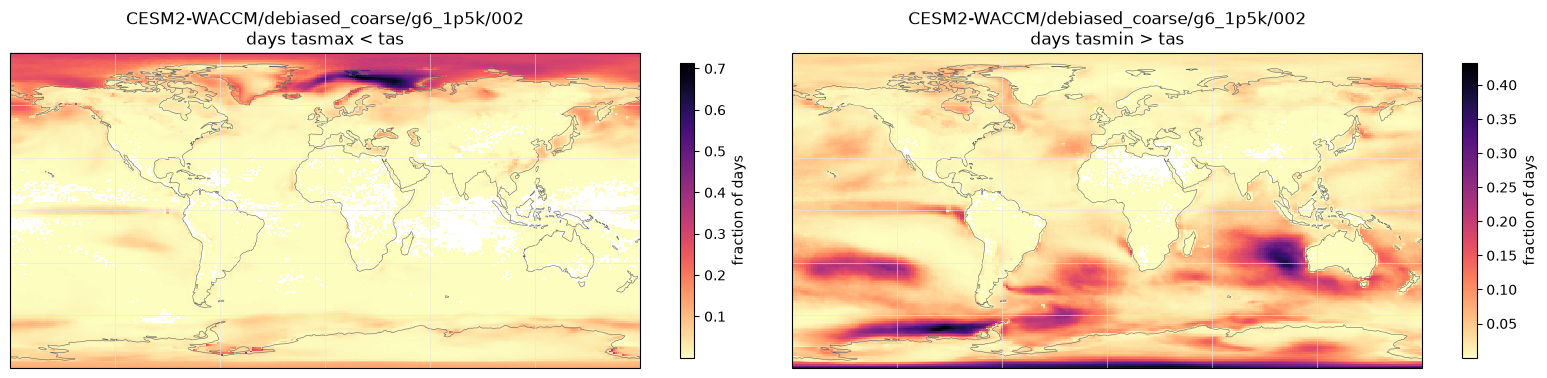

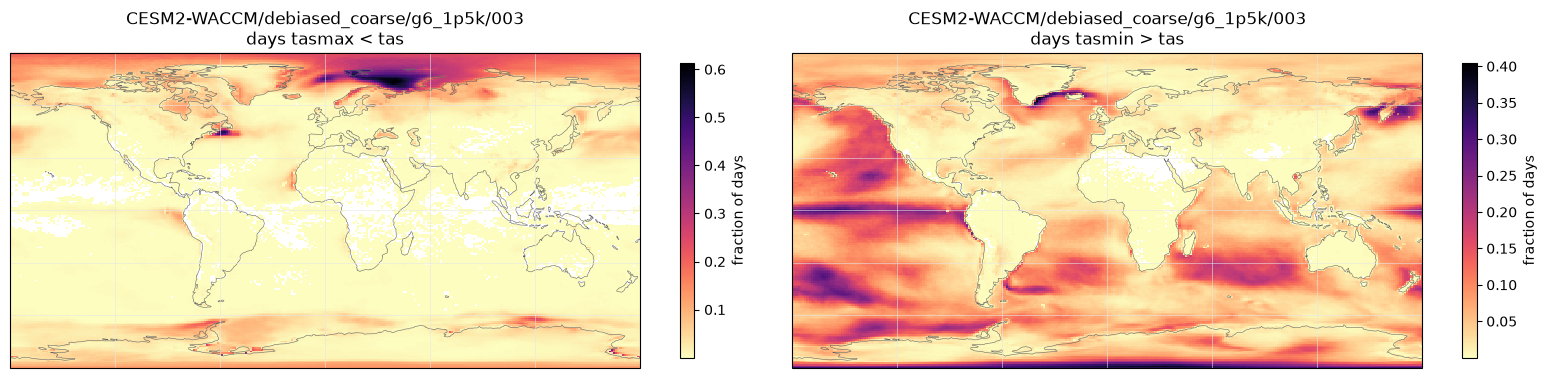

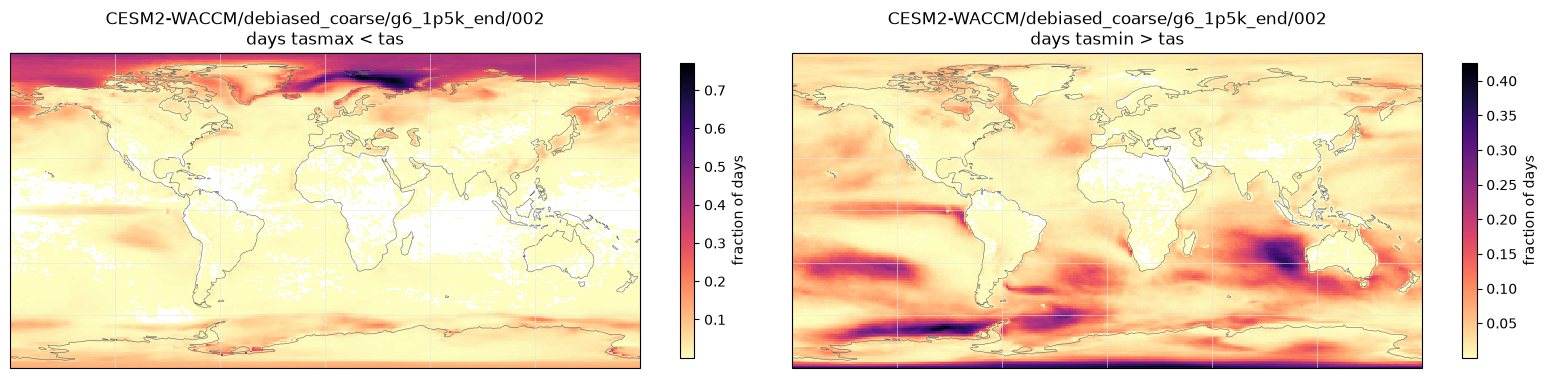

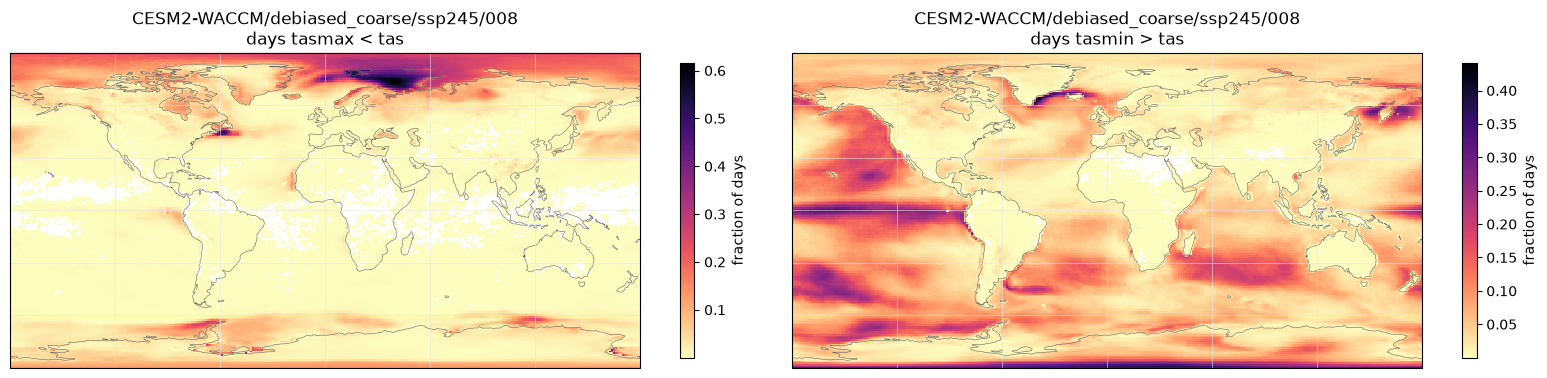

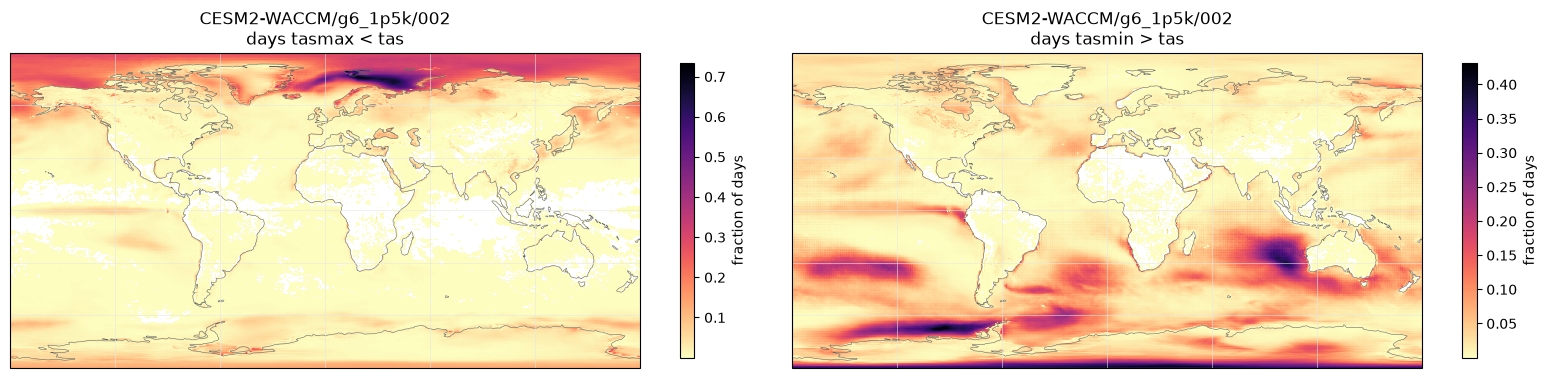

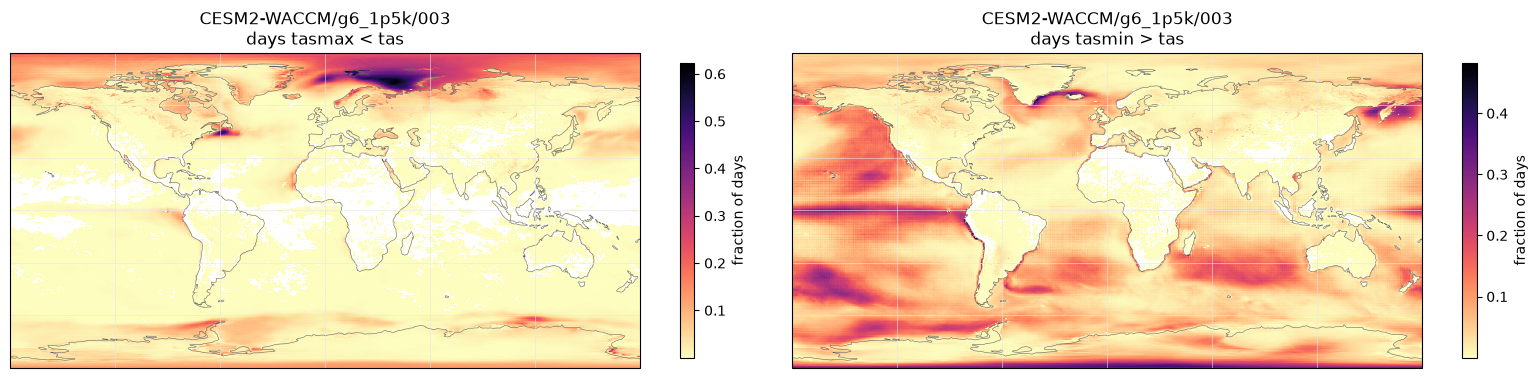

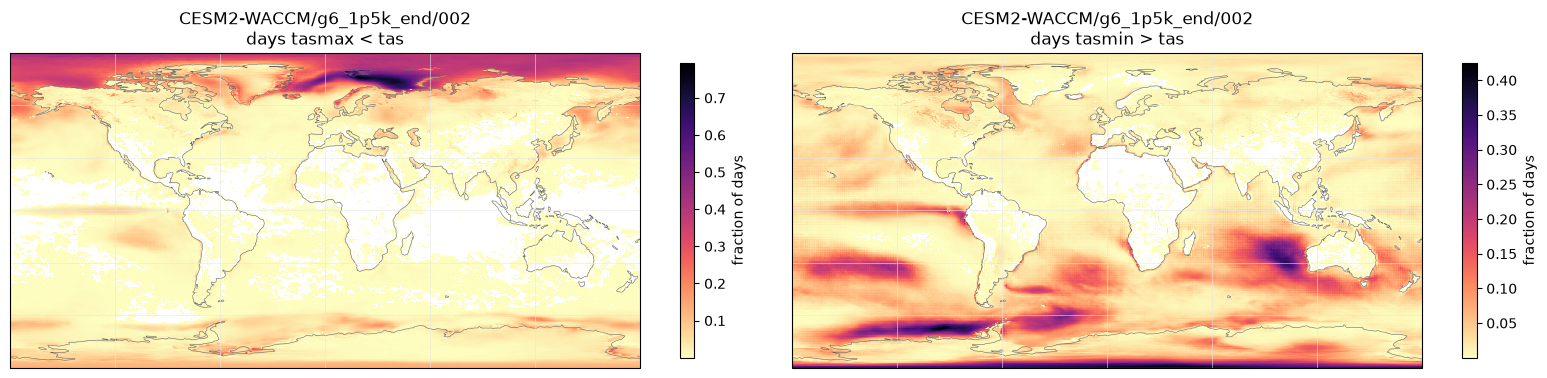

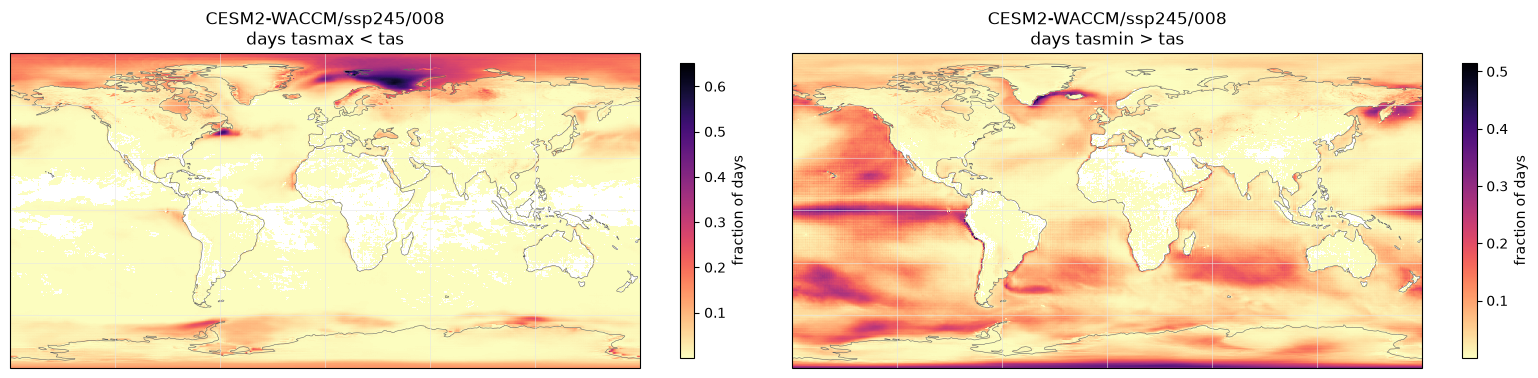

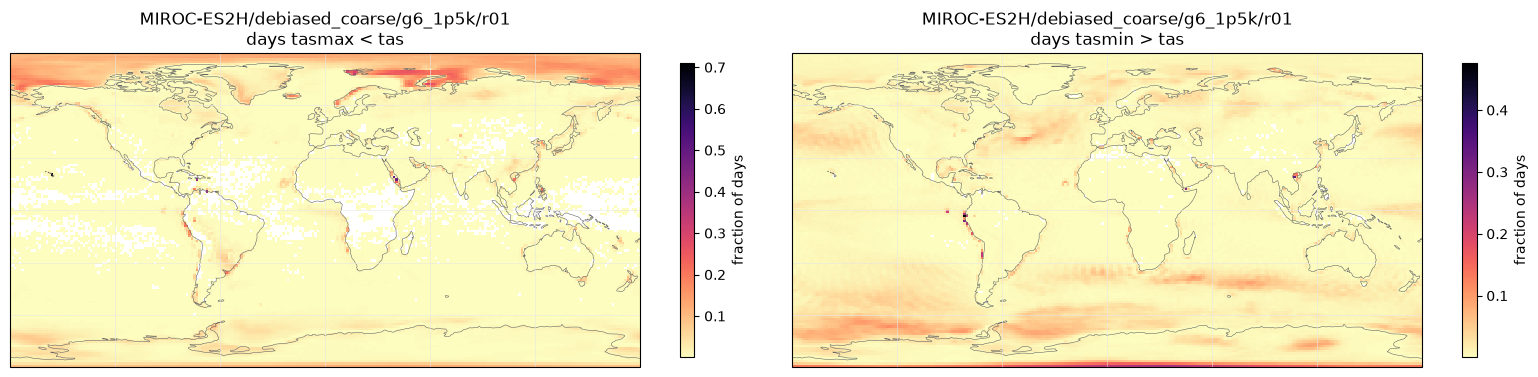

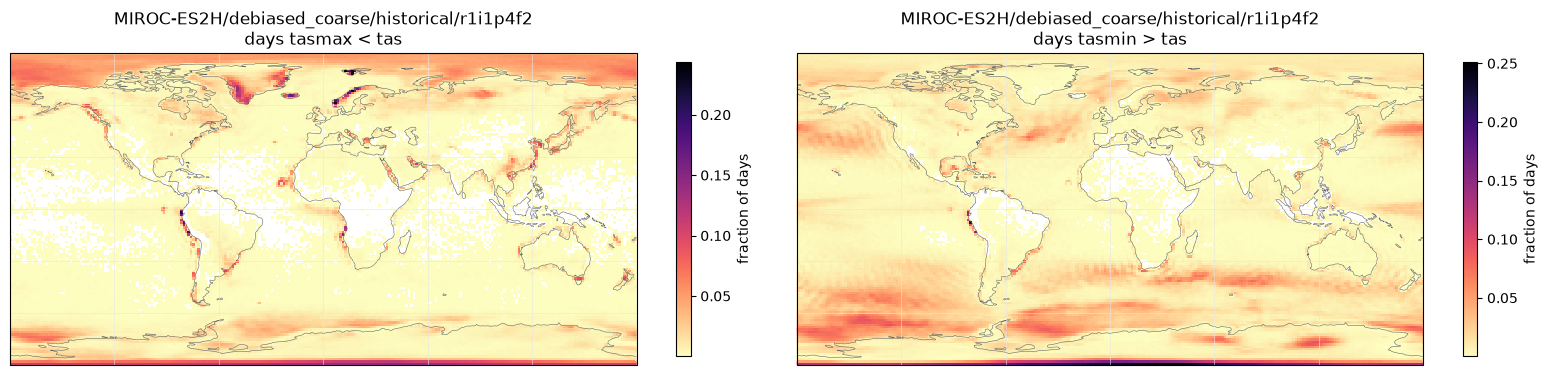

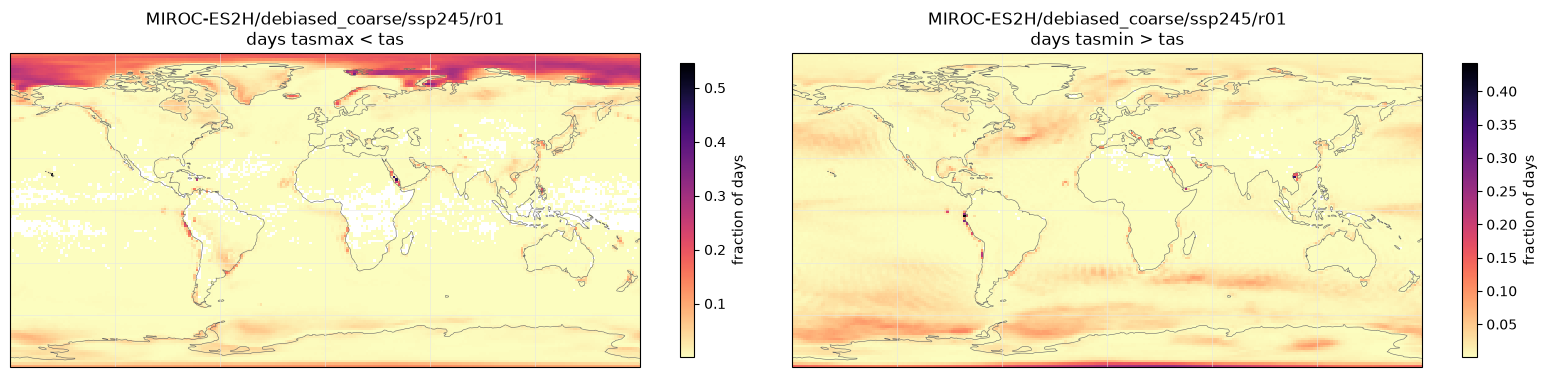

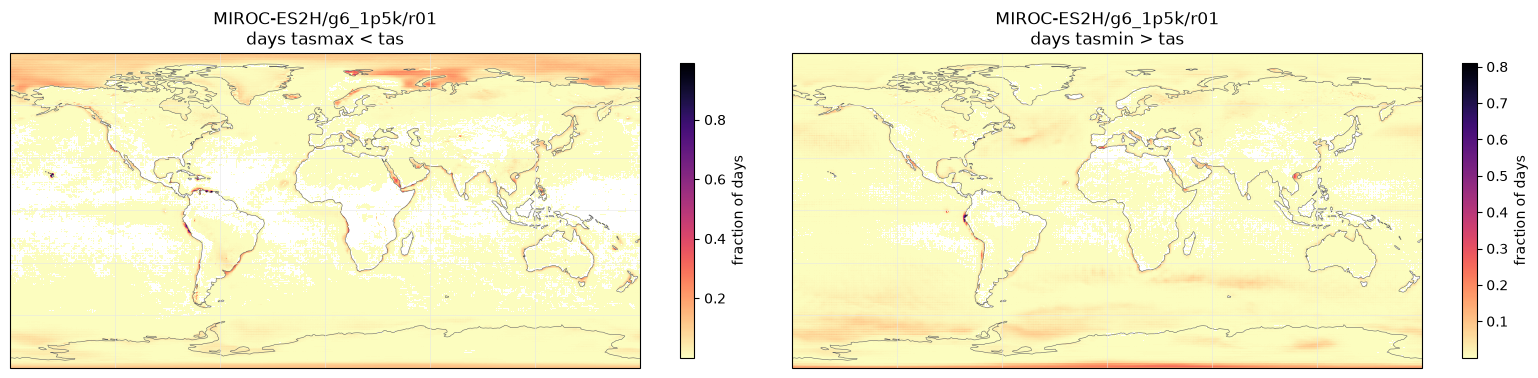

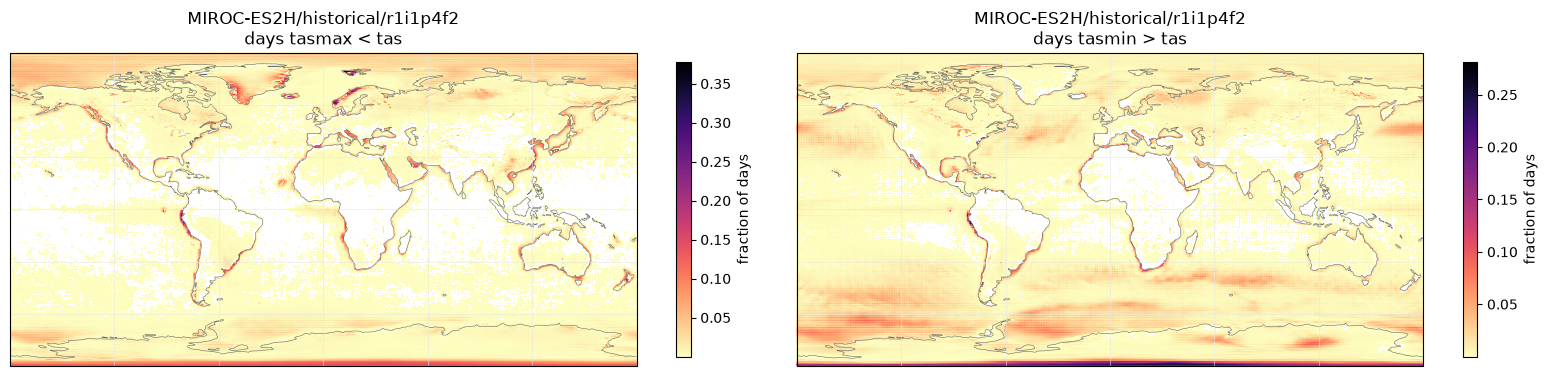

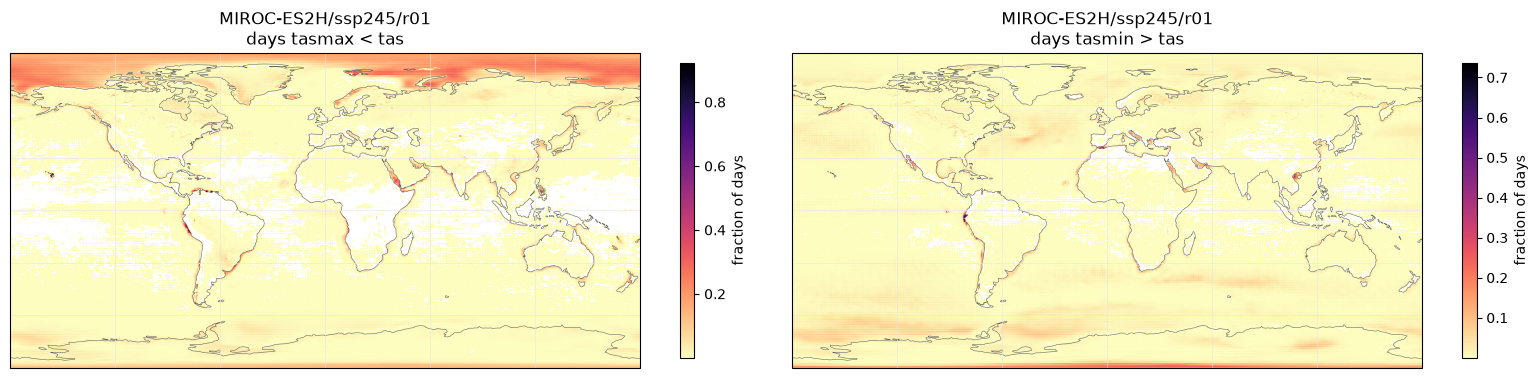

In [10]:
plot_violation_maps(viol)

### Land, ocean, and high latitudes

Each triplet's two diagnostic conditions split across five regions (global, land, ocean, land/ocean
below 60° latitude, poleward of 60°), area-weighted by cos(latitude) on a Natural Earth land mask of
cell centers.

Both GCMs break `tasmin > tas` far more often over ocean than over land, but not by the same factor:
CESM2-WACCM runs 6 to 8 times more often over water, MIROC-ES2H only 3 to 3.4. `tasmax < tas` is
close to even in both (0.9 to 1.7). That the violations track surface type rather than clustering on
grid artifacts is consistent with `tasmin` being bias-corrected from `dtr` and then downscaled, since
the small diurnal range over water is where that path has least room; the gap between the two models
suggests how much of it is model-specific rather than intrinsic to the method.

In [11]:
regional_df = regional_consistency_summary(viol)
display(highlight(regional_df))

# How many times more often a unit of ocean area breaks the ordering than a unit of land area.
# "land 0" means the ordering never broke over land.
print("\nocean:land ratio of mean violation frequency")
for gcm, group, member in viol:
    parts = []
    for label in ("max<tas", "min>tas"):
        over_land = regional_df.loc[(gcm, group, member, "land"), f"mean_freq_{label}"]
        over_ocean = regional_df.loc[(gcm, group, member, "ocean"), f"mean_freq_{label}"]
        parts.append(f"{label}: {over_ocean / over_land:.1f}x" if over_land else f"{label}: land 0")
    print(f"  {gcm}/{group}/{member}  " + "   ".join(parts))


ocean:land ratio of mean violation frequency
  CESM2-WACCM/debiased_coarse/g6_1p5k/002  max<tas: 1.4x   min>tas: 6.2x
  CESM2-WACCM/debiased_coarse/g6_1p5k/003  max<tas: 1.3x   min>tas: 7.3x
  CESM2-WACCM/debiased_coarse/g6_1p5k_end/002  max<tas: 1.5x   min>tas: 6.4x
  CESM2-WACCM/debiased_coarse/ssp245/008  max<tas: 1.3x   min>tas: 7.4x
  CESM2-WACCM/g6_1p5k/002  max<tas: 1.6x   min>tas: 6.4x
  CESM2-WACCM/g6_1p5k/003  max<tas: 1.4x   min>tas: 7.6x
  CESM2-WACCM/g6_1p5k_end/002  max<tas: 1.7x   min>tas: 6.7x
  CESM2-WACCM/ssp245/008  max<tas: 1.4x   min>tas: 7.8x
  MIROC-ES2H/debiased_coarse/g6_1p5k/r01  max<tas: 1.2x   min>tas: 3.2x
  MIROC-ES2H/debiased_coarse/historical/r1i1p4f2  max<tas: 0.9x   min>tas: 3.4x
  MIROC-ES2H/debiased_coarse/ssp245/r01  max<tas: 1.4x   min>tas: 3.1x
  MIROC-ES2H/g6_1p5k/r01  max<tas: 1.6x   min>tas: 3.2x
  MIROC-ES2H/historical/r1i1p4f2  max<tas: 1.1x   min>tas: 3.2x
  MIROC-ES2H/ssp245/r01  max<tas: 2.0x   min>tas: 3.2x


## Part 3: precipitation physical constraints (issue #459)

`pr` must never go negative, and no day may carry an outlandishly large total (2000 mm/day, against
a largest-recorded ~1825 mm/day). Both are counted per cell in the Part 1 pass, so this section only
summarizes and maps. See [#459](https://github.com/carbonplan/srm-downscaling/issues/459).

In [12]:
pr_physical_df = pr_physical_summary(pr_phys)
display(highlight(pr_physical_df))

n_neg = int(pr_physical_df["neg_cell_days"].sum())
n_high = int(pr_physical_df["high_cell_days"].sum())
print(f"\nNon-negativity holds everywhere (pr >= 0): {n_neg == 0} (negative cell-days: {n_neg})")
print(f"No outlandish daily totals: {n_high == 0} (outlandish cell-days: {n_high})")


Non-negativity holds everywhere (pr >= 0): True (negative cell-days: 0)
No outlandish daily totals: True (outlandish cell-days: 0)


In [13]:
plot_negativity_maps(pr_phys)

# Report-only, over the Part 1 fingerprints, restricted to pr leaves.
flagged = {k: pr_high_days(s.fingerprint) for k, s in stats.items() if k[2] == "pr"}
flagged = {k: days for k, days in flagged.items() if days}
if flagged:
    print("Outlandish precip days (report-only, spatial max > 2000 mm/day):")
    for key, days in flagged.items():
        print(f"  {'/'.join(key)}: {len(days)} days")
        for date, val in days:
            print(f"    {date}  {val:.3e} kg m-2 s-1 ({val * 86400:.0f} mm/day)")
else:
    print("No outlandish precip days flagged.")

No leaf has any negative precipitation, nothing to map.
No outlandish precip days flagged.


## Summary

Three parts, run per GCM against the published production stores on branch `v0.13.0`:

- **Part 1** (#450): five per-leaf checks plus four that reuse the same pass. Checks 6 to 9 answer
  the questions a pass/fail table alone leaves open: are the leaves distinct, is the expected set
  present, is each time axis complete, and is every leaf on the right grid.
- **Part 2** (#448): `tasmin ≤ tas ≤ tasmax` per triplet. `tasmax ≥ tasmin` should hold everywhere
  (#331); the other two are diagnostic. MIROC-ES2H is the first GCM whose historical period forms a
  triplet, since CESM2-WACCM stores `tas` and `tasmax`/`tasmin` under different historical members.
- **Part 3** (#459): precipitation non-negativity and outlandish daily totals, per `pr` leaf.

The checks themselves live in `srm.qaqc`, shared with the regional notebook, and are unit-tested in
`tests/test_qaqc.py`.

In [14]:
cluster.shutdown()

2026-08-07 23:46:08,540 - distributed.deploy.adaptive - INFO - Adaptive scaling stopped: minimum=50 maximum=50. Reason: unknown
